<a href="https://colab.research.google.com/github/Nehasatheesh04/computer-vision/blob/main/computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement SIFT based image matching between 2 images and visualise the matched key points

In [ ]:
pip install opencv-contrib-python


In [ ]:
import urllib.request
import cv2
import matplotlib.pyplot as plt

# URLs for the standard OpenCV tutorial images
url1 = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/box.png"
url2 = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/box_in_scene.png"

# Download the images
urllib.request.urlretrieve(url1, "box.png")
urllib.request.urlretrieve(url2, "box_in_scene.png")

print("Images downloaded successfully as 'box.png' and 'box_in_scene.png'")

# Load and visualize to confirm
img1 = cv2.imread('box.png')
img2 = cv2.imread('box_in_scene.png')

Images downloaded successfully as 'box.png' and 'box_in_scene.png'


Keypoints in Image 1: 604
Keypoints in Image 2: 969
Good matches: 80


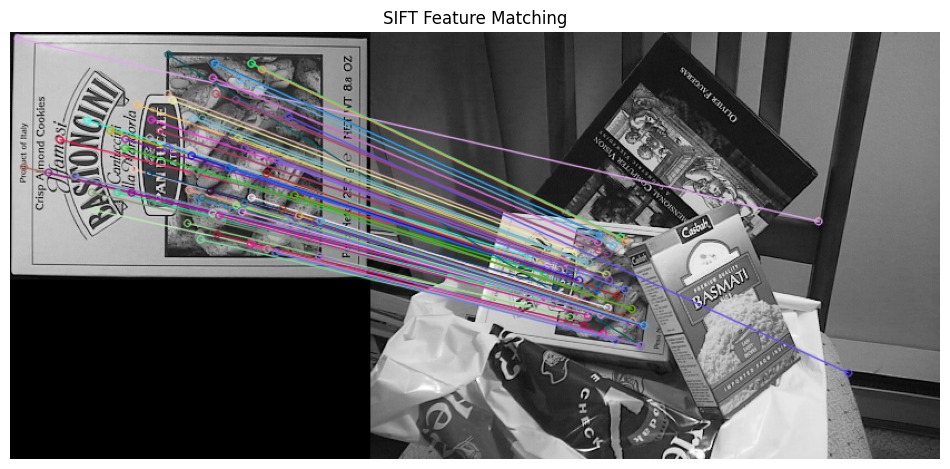

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Read images (grayscale)
img1 = cv2.imread('/content/box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/box_in_scene.png', cv2.IMREAD_GRAYSCALE)

# Check if images loaded
if img1 is None or img2 is None:
    print("Error loading images")
    exit()

# 2. Create SIFT object
sift = cv2.SIFT_create()

# 3. Detect keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print(f"Keypoints in Image 1: {len(kp1)}")
print(f"Keypoints in Image 2: {len(kp2)}")

# 4. Match descriptors using BFMatcher
bf = cv2.BFMatcher(cv2.NORM_L2)

matches = bf.knnMatch(des1, des2, k=2)

# 5. Apply Lowe's Ratio Test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Good matches: {len(good_matches)}")

# 6. Draw matched keypoints
matched_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# 7. Display result
plt.figure(figsize=(12,6))
plt.imshow(matched_img, cmap='gray')
plt.title('SIFT Feature Matching')
plt.axis('off')
plt.show()


Implement a pedestrian detection system using HOG and SVM and evaluate the accuracy

In [ ]:
pip install opencv-python scikit-learn matplotlib -q


In [ ]:
import cv2
import numpy as np
import os
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize HOG descriptor
hog = cv2.HOGDescriptor(
    _winSize=(64, 128),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

In [ ]:
# 2. Define the HOG feature extraction function
def extract_hog_features(folder, prefix=None):
    features = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

    for file in os.listdir(folder):
        if prefix and not file.startswith(prefix):
            continue
        if not file.lower().endswith(valid_extensions):
            continue

        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (64, 128))
        hog_features = hog.compute(img)
        features.append(hog_features.flatten())

    return features

In [ ]:
# 3. Search for the training image folder recursively
def find_jpeg_folder_recursive(root_path):
    for root, dirs, files in os.walk(root_path):
        if 'JPEGImages' in dirs and 'train' in root.lower():
            return os.path.join(root, 'JPEGImages')
    return None

train_path = find_jpeg_folder_recursive('/content/')
print(f"Training folder located at: {train_path}")

Training folder located at: /content/drive/MyDrive/archive (3)/Train/JPEGImages


In [ ]:
# 4. Load features for both classes (person and crop)
print("Extracting HOG features...")
pos_features = extract_hog_features(train_path, prefix="person")
neg_features = extract_hog_features(train_path, prefix="crop")

print(f"Loaded {len(pos_features)} positive samples and {len(neg_features)} negative samples.")

Extracting HOG features...
Loaded 209 positive samples and 405 negative samples.


In [ ]:
# 5. Prepare data and train the Linear SVM model
X = np.array(pos_features + neg_features)
y = np.array([1]*len(pos_features) + [0]*len(neg_features))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training SVM model...")
svm = LinearSVC(max_iter=2000, dual=False)
svm.fit(X_train, y_train)

Training SVM model...


LinearSVC(dual=False, max_iter=2000)

In [ ]:
# 6. Evaluate accuracy and print report
y_pred = svm.predict(X_test)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.7561

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.88      0.82        76
           1       0.74      0.55      0.63        47

    accuracy                           0.76       123
   macro avg       0.75      0.72      0.73       123
weighted avg       0.75      0.76      0.75       123



design and implement a method to determine whether two shapes are similiar using geometric moments.compute normlaised central moments ,hu moments

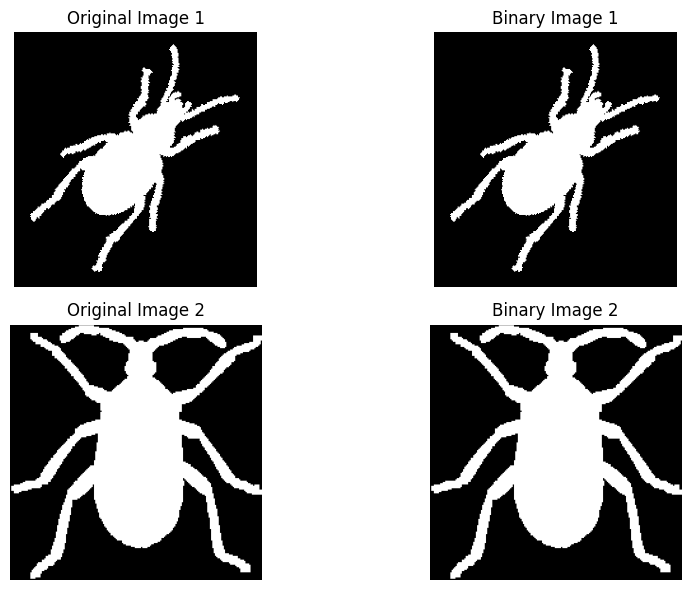


Normalized Central Moments:
nu20: 0.0005169205850245252
nu11: -0.00032925455513177964
nu02: 0.0006424419317305297

Normalized Central Moments:
nu20: 0.0004226937565723002
nu11: -2.6300583244566757e-05
nu02: 0.0006683353181835898

Hu Moments Image 1: [  2.93578071   6.3472801    9.7207955    9.94796336  10.
   9.99996294 -10.        ]
Hu Moments Image 2: [  2.96216364   7.19923716   9.83759823   9.96911723  10.
   9.99999197 -10.        ]

L1 Distance: 1.0163256188179157
Cosine Similarity: 0.9994119882001028
Result: Shapes are SIMILAR


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def preprocess(image_path):
    # Read original grayscale image
    original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Threshold to binary
    _, thresh = cv2.threshold(original, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return original, thresh

def show_images(orig1, bin1, orig2, bin2):
    plt.figure(figsize=(10, 6))

    plt.subplot(2, 2, 1)
    plt.title("Original Image 1")
    plt.imshow(orig1, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.title("Binary Image 1")
    plt.imshow(bin1, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.title("Original Image 2")
    plt.imshow(orig2, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.title("Binary Image 2")
    plt.imshow(bin2, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def compute_moments(binary_img):
    moments = cv2.moments(binary_img)

    print("\nNormalized Central Moments:")
    print("nu20:", moments['nu20'])
    print("nu11:", moments['nu11'])
    print("nu02:", moments['nu02'])

    hu = cv2.HuMoments(moments)

    # Log transform
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    return hu.flatten()

def compare_shapes(hu1, hu2):
    l1_distance = np.sum(np.abs(hu1 - hu2))
    cosine_sim = cosine_similarity([hu1], [hu2])[0][0]

    print("\nHu Moments Image 1:", hu1)
    print("Hu Moments Image 2:", hu2)

    print("\nL1 Distance:", l1_distance)
    print("Cosine Similarity:", cosine_sim)

    if l1_distance < 3 or cosine_sim > 0.90:
        print("Result: Shapes are SIMILAR")
    else:
        print("Result: Shapes are DIFFERENT")


# 🔹 Input image paths
image1_path = "/content/beetle-12.gif"
image2_path = "/content/beetle-13.gif"

# Preprocess
orig1, bin1 = preprocess(image1_path)
orig2, bin2 = preprocess(image2_path)

# Show images
show_images(orig1, bin1, orig2, bin2)

# Compute moments
hu1 = compute_moments(bin1)
hu2 = compute_moments(bin2)

# Compare
compare_shapes(hu1, hu2)

Implement block matching using SAD (Sum of Absolute Differences) to estimate motion between two images.

In [ ]:
import cv2

# Load the images in grayscale
img1 = cv2.imread('/content/RIMG_1.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/RIMG_2.png', cv2.IMREAD_GRAYSCALE)

# Verify that both images were loaded successfully
if img1 is None or img2 is None:
    print("Error: One or both images could not be loaded. Please ensure 'RIMG_1.png' and 'RIMG_2.png' exist in the /content/ directory.")
else:
    print("Images 'RIMG_1.png' and 'RIMG_2.png' loaded successfully as grayscale.")

Images 'RIMG_1.png' and 'RIMG_2.png' loaded successfully as grayscale.


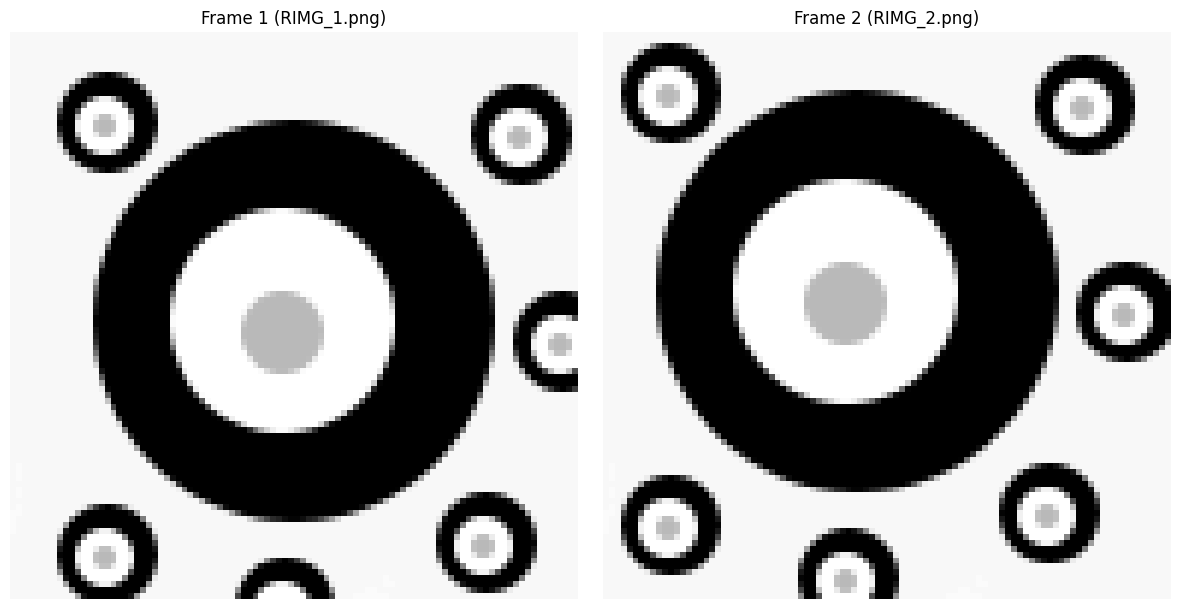

In [ ]:
import matplotlib.pyplot as plt

# Assuming img1 and img2 are available from previous steps

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Frame 1 (RIMG_1.png)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('Frame 2 (RIMG_2.png)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
block_size = 16
search_range = 8

print(f"Block size: {block_size}")
print(f"Search range: {search_range}")

Block size: 16
Search range: 8


In [ ]:
def sad(block1, block2):
    """
    Calculates the Sum of Absolute Differences (SAD) between two blocks.
    """
    return np.sum(np.abs(block1 - block2))

In [ ]:
import numpy as np

def find_motion_vectors(img1, img2, block_size, search_range):
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    motion_vectors = []

    # Iterate through each block in the current image (img2)
    for y in range(0, h2 - block_size + 1, block_size):
        for x in range(0, w2 - block_size + 1, block_size):
            current_block = img2[y : y + block_size, x : x + block_size]

            min_sad = float('inf')
            best_dx, best_dy = 0, 0

            # Define search window in reference image (img1)
            # The search area is centered around the current block's position in img1
            # but constrained by image boundaries and search_range
            search_y_start = max(0, y - search_range)
            search_y_end = min(h1 - block_size, y + search_range)
            search_x_start = max(0, x - search_range)
            search_x_end = min(w1 - block_size, x + search_range)

            # Perform exhaustive search within the defined range in img1
            for dy in range(search_y_start, search_y_end + 1):
                for dx in range(search_x_start, search_x_end + 1):
                    ref_block = img1[dy : dy + block_size, dx : dx + block_size]
                    current_sad = sad(current_block, ref_block)

                    if current_sad < min_sad:
                        min_sad = current_sad
                        # The motion vector is the difference between the top-left corner
                        # of the best match block in img1 and the current block in img2
                        best_dx = dx - x
                        best_dy = dy - y

            # Store the motion vector (x_current, y_current, dx, dy)
            motion_vectors.append((x, y, best_dx, best_dy))

    return motion_vectors

motion_vectors = find_motion_vectors(img1, img2, block_size, search_range)
print(f"Computed {len(motion_vectors)} motion vectors.")

Computed 36 motion vectors.


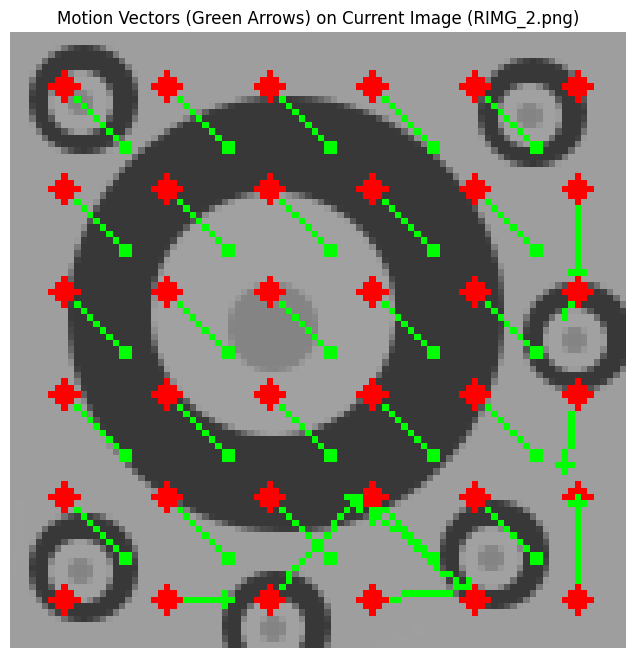

In [ ]:
import matplotlib.pyplot as plt

def draw_motion_vectors(img, motion_vectors, block_size, scale_factor=2):
    """
    Draws motion vectors on the given image.
    """
    # Convert grayscale image to BGR for drawing colored vectors
    display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    for (x, y, dx, dy) in motion_vectors:
        # Calculate the center of the current block
        center_x = x + block_size // 2
        center_y = y + block_size // 2

        # Calculate the end point of the motion vector
        end_x = int(center_x + dx * scale_factor)
        end_y = int(center_y + dy * scale_factor)

        # Draw the motion vector as an arrow
        cv2.arrowedLine(
            display_img,
            (center_x, center_y),
            (end_x, end_y),
            (0, 255, 0), # Green color
            1,
            tipLength=0.1
        )
        # Optionally, draw a circle at the start of the vector
        cv2.circle(display_img, (center_x, center_y), 2, (0, 0, 255), -1) # Red dot

    return display_img

# Draw motion vectors on img2
output_image = draw_motion_vectors(img2, motion_vectors, block_size)

# Display the result
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('Motion Vectors (Green Arrows) on Current Image (RIMG_2.png)')
plt.axis('off')
plt.show()

Implement 2D Image registration b/w two images using feature matching.Implement affine transformations on an image . Recognize an object in a scene using local feature matching

image registration

In [1]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import os

# URLs for the standard OpenCV tutorial images
url1 = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/box.png"
url2 = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/box_in_scene.png"

# Download the images if they don't exist
if not os.path.exists('box.png'):
    urllib.request.urlretrieve(url1, "box.png")
    print("Downloaded 'box.png'")
if not os.path.exists('box_in_scene.png'):
    urllib.request.urlretrieve(url2, "box_in_scene.png")
    print("Downloaded 'box_in_scene.png'")

# 1. Load 'box.png' and 'box_in_scene.png' in grayscale
img1 = cv2.imread('/content/box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('/content/box_in_scene.png', cv2.IMREAD_GRAYSCALE)

# Check if images loaded successfully
if img1 is None or img2 is None:
    print("Error: One or both images could not be loaded even after attempting download. Exiting.")
    exit()
else:
    print("Images 'box.png' and 'box_in_scene.png' loaded successfully as grayscale.")

# 2. Initialize a SIFT detector
sift = cv2.SIFT_create()

# 3. Detect keypoints and compute descriptors for both img1 and img2
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Print the number of keypoints found in each image
print(f"Keypoints found in img1 (box.png): {len(kp1)}")
print(f"Keypoints found in img2 (box_in_scene.png): {len(kp2)}")

# 4. Initialize a Brute-Force Matcher with NORM_L2
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# 5. Use knnMatch to find the two best matches for each descriptor
# Ensure descriptors are not None before matching
matches = []
if des1 is not None and des2 is not None and len(des1) > 0 and len(des2) > 0:
    matches = bf.knnMatch(des1, des2, k=2)
elif des1 is None or len(des1) == 0:
    print("Warning: No descriptors found for img1, cannot perform matching.")
    matches = []
elif des2 is None or len(des2) == 0:
    print("Warning: No descriptors found for img2, cannot perform matching.")
    matches = []
else:
    print("Warning: Descriptors are empty for an unknown reason, cannot perform matching.")
    matches = []

# 6. Apply Lowe's Ratio Test to filter the matches
good_matches = []
if matches:
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

# 7. Print the number of good matches
print(f"Good matches found after Lowe's Ratio Test: {len(good_matches)}")

Downloaded 'box.png'
Downloaded 'box_in_scene.png'
Images 'box.png' and 'box_in_scene.png' loaded successfully as grayscale.
Keypoints found in img1 (box.png): 604
Keypoints found in img2 (box_in_scene.png): 969
Good matches found after Lowe's Ratio Test: 80


In [2]:
import numpy as np

# 1. Extract the coordinates of matched keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# 2. Compute Homography matrix using RANSAC
# The RANSAC method is used to handle potential outliers in the matches
# ransacReprojThreshold is the maximum allowed reprojection error to treat a point pair as an inlier
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# 3. Print the number of inliers found by RANSAC
inliers_count = np.sum(mask)
print(f"Homography computed with {inliers_count} inliers (out of {len(good_matches)} good matches).")

# 4. Flatten the mask array to a list
matches_mask = mask.ravel().tolist()

Homography computed with 75 inliers (out of 80 good matches).


In [3]:
import cv2

# 1. Get the height and width of 'box_in_scene.png' (img2)
h, w = img2.shape[:2]

# 2. Use cv2.warpPerspective to transform 'box.png' (img1) using the homography matrix H
# The output size should be the same as 'box_in_scene.png'
img1_registered = cv2.warpPerspective(img1, H, (w, h))

print("Image 'box.png' successfully warped and registered to the perspective of 'box_in_scene.png'.")

Image 'box.png' successfully warped and registered to the perspective of 'box_in_scene.png'.


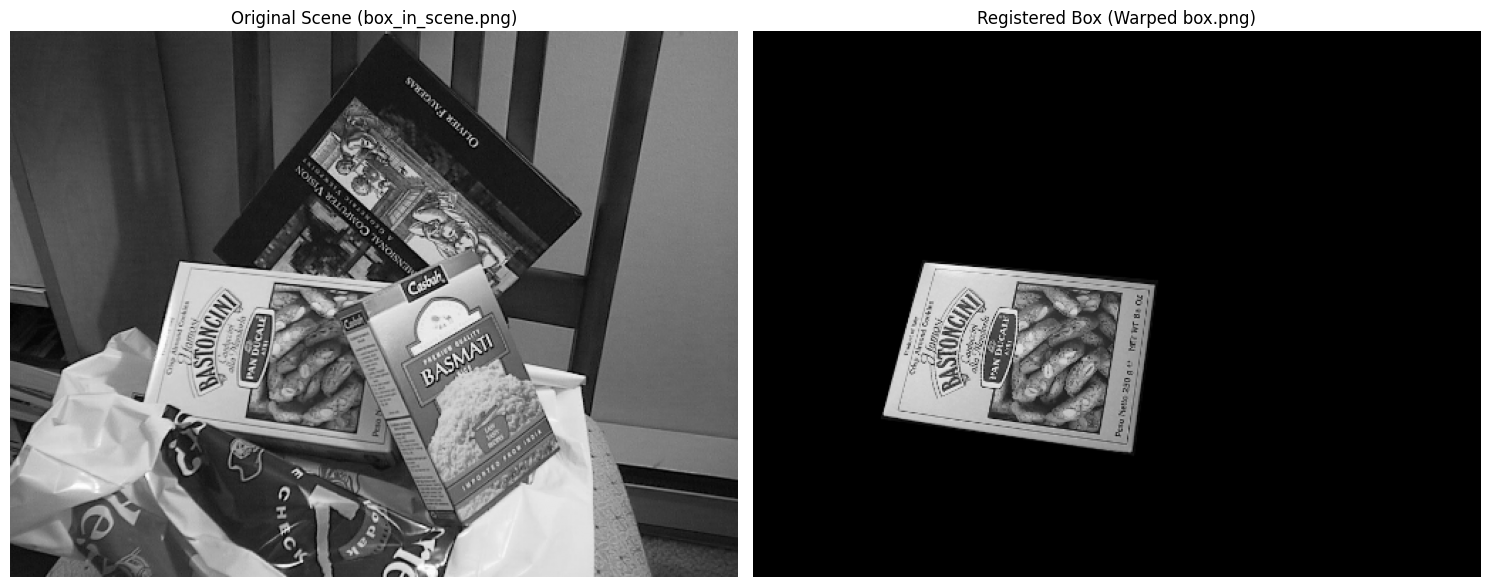

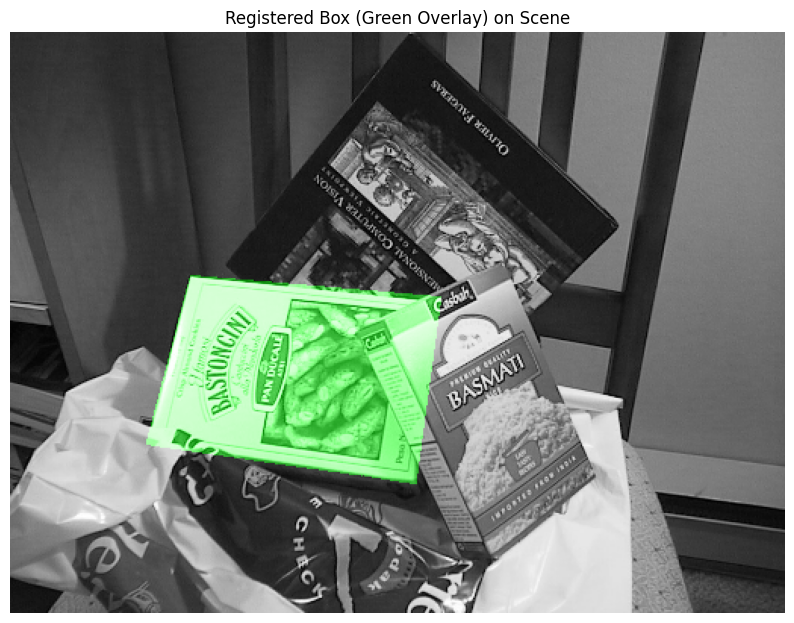

Visualized image registration results.


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Ensure img1 (box.png), img2 (box_in_scene.png), and img1_registered are available from previous steps

# 1. Create a plot showing img1_registered and img2 side-by-side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')
plt.title('Original Scene (box_in_scene.png)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img1_registered, cmap='gray')
plt.title('Registered Box (Warped box.png)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 2. Create an overlaid image to visualize the alignment
# Convert img2 to 3-channel for color overlay
img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

# Create a mask for the registered object (where img1_registered is not black)
# This helps to only overlay the actual object, not the black background from warping
mask = img1_registered > 0
mask = mask.astype(np.uint8) * 255

# Create a green overlay for the registered object
green_overlay = np.zeros_like(img2_color, dtype=np.uint8)
green_overlay[mask > 0] = [0, 255, 0] # Green color

# Blend the green overlay with the original scene image
alignment_visualization = cv2.addWeighted(img2_color, 1, green_overlay, 0.5, 0)

# 3. Display the overlaid visualization
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(alignment_visualization, cv2.COLOR_BGR2RGB))
plt.title('Registered Box (Green Overlay) on Scene')
plt.axis('off')
plt.show()

print("Visualized image registration results.")

object recognition

In [5]:
import numpy as np
import cv2

# Get the height and width of the object image (img1 which is box.png)
h_img1, w_img1 = img1.shape[:2]

# Define the 4 corners of the object image (img1)
# These are (0,0), (w_img1, 0), (w_img1, h_img1), (0, h_img1)
obj_corners = np.float32([
    [0, 0],
    [w_img1, 0],
    [w_img1, h_img1],
    [0, h_img1]
]).reshape(-1, 1, 2)

# Transform the object's corners using the computed homography matrix H
# This gives the corresponding points in the scene image (img2)
scene_corners = cv2.perspectiveTransform(obj_corners, H)

print("Original object corners:\n", obj_corners)
print("Transformed scene corners:\n", scene_corners)

Original object corners:
 [[[  0.   0.]]

 [[324.   0.]]

 [[324. 223.]]

 [[  0. 223.]]]
Transformed scene corners:
 [[[118.84465 160.91919]]

 [[284.7064  175.13289]]

 [[267.97925 298.63364]]

 [[ 89.4505  272.6221 ]]]


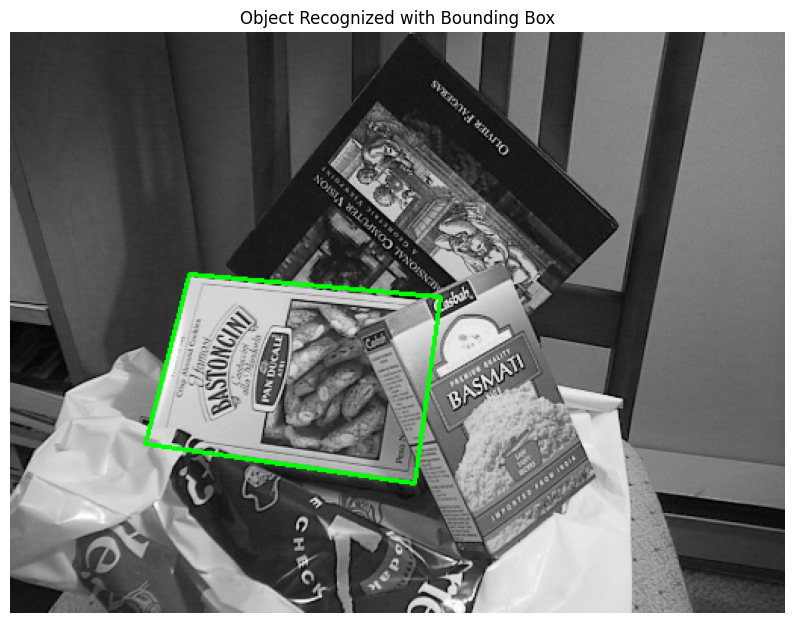

Bounding box drawn on 'box_in_scene.png' and displayed.


In [6]:
import cv2
import matplotlib.pyplot as plt

# Make a copy of img2 (box_in_scene.png) to draw on
img_bbox = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

# Draw the bounding box on the scene image
# The scene_corners are already in the correct format (N, 1, 2) for polylines
# The argument isTrue specifies whether the polylines are closed or not. If true, the polygon is drawn.
cv2.polylines(img_bbox, [np.int32(scene_corners)], isClosed=True, color=(0, 255, 0), thickness=2)

# Display the image with the bounding box
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB))
plt.title('Object Recognized with Bounding Box')
plt.axis('off')
plt.show()

print("Bounding box drawn on 'box_in_scene.png' and displayed.")

affine transformation

In [7]:
import cv2

# The image 'box.png' is already loaded as img1 from previous steps.
# Assign img1 to img_affine as required by the subtask.
img_affine = img1

# Verify that the image is loaded and its shape
if img_affine is not None:
    print(f"Image 'box.png' loaded successfully as img_affine with shape: {img_affine.shape}")
else:
    print("Error: Image 'box.png' could not be loaded into img_affine.")

Image 'box.png' loaded successfully as img_affine with shape: (223, 324)


In [8]:
import numpy as np

# Get dimensions of the image for defining points
h, w = img_affine.shape[:2]
print(f"Image dimensions (height, width): ({h}, {w})")

# Define 3 source points in the original image (img_affine)
# For example, corners or other distinct features
src_pts = np.float32([
    [0, 0],         # Top-left
    [w - 1, 0],     # Top-right
    [0, h - 1]      # Bottom-left
])

# Define 3 corresponding destination points in the transformed image
# These points will determine the rotation, scaling, and translation
# Example: slight translation, rotation, and scaling
dst_pts = np.float32([
    [w * 0.1, h * 0.2],   # New position for top-left
    [w * 0.8, h * 0.1],   # New position for top-right
    [w * 0.2, h * 0.9]    # New position for bottom-left
])

print("Source points defined:", src_pts)
print("Destination points defined:", dst_pts)

Image dimensions (height, width): (223, 324)
Source points defined: [[  0.   0.]
 [323.   0.]
 [  0. 222.]]
Destination points defined: [[ 32.4  44.6]
 [259.2  22.3]
 [ 64.8 200.7]]


In [9]:
import cv2

# Compute the affine transformation matrix (M)
M = cv2.getAffineTransform(src_pts, dst_pts)

print("Affine Transformation Matrix (M):")
print(M)

Affine Transformation Matrix (M):
[[ 0.70216722  0.14594595 32.40000153]
 [-0.06904025  0.70315315 44.59999847]]


Affine transformation applied successfully.


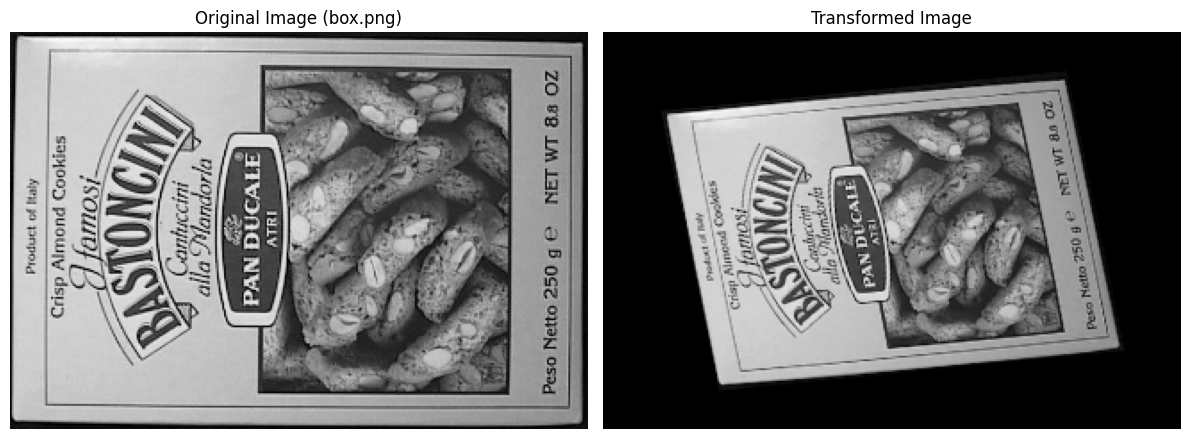

In [10]:
import cv2
import matplotlib.pyplot as plt

# Apply the affine transformation
# The output image will have the same dimensions as the original for simplicity
img_transformed = cv2.warpAffine(img_affine, M, (w, h))

print("Affine transformation applied successfully.")

# Visualize the original and transformed images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_affine, cmap='gray')
plt.title('Original Image (box.png)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_transformed, cmap='gray')
plt.title('Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()
